<a href="https://colab.research.google.com/github/ShariUWI/carisurg-portfolio/blob/main/SOliver_Week6_Baseline_Model_Interim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6 Interim Submission  
## Building a Baseline Model for AI-Assisted ED Triage

**Prepared by:** Shari Oliver  
**Programme:** CariSurg MedTech Pathways Healthcare AI Programme  
**Dataset:** `yaleemmlc_admissionprediction_triage.csv`  
**Project:** AI-Assisted Emergency Department Triage Support  

### Interim Goal

The goal of this interim notebook is to train a defensible first baseline model on the Mercer ED triage dataset and evaluate whether it performs better than a simple random baseline. For the interim submission, the focus is on training at least one baseline model, reviewing initial evaluation metrics, and producing a draft confusion matrix.

The primary clinical concern is whether the model misses high-acuity ESI Level 1 patients. In emergency triage, missing a critically ill patient is more serious than over-triaging a lower-risk patient.

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = Path("yaleemmlc_admissionprediction_triage.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset not found. Upload yaleemmlc_admissionprediction_triage.csv "
        "to this notebook environment or update DATA_PATH."
    )

df = pd.read_csv(DATA_PATH, index_col=0)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

df.head()

Dataset loaded successfully.
Rows: 55,121
Columns: 225


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,cc_abscess,cc_addictionproblem,cc_agitation,cc_alcoholintoxication,cc_alcoholproblem,cc_allergicreaction,cc_alteredmentalstatus,cc_animalbite,cc_ankleinjury,cc_anklepain,cc_anxiety,cc_arminjury,cc_armpain,cc_armswelling,cc_assaultvictim,cc_asthma,cc_backpain,cc_bleeding/bruising,cc_blurredvision,cc_bodyfluidexposure,...,cc_post-opproblem,cc_psychiatricevaluation,cc_psychoticsymptoms,cc_rapidheartrate,cc_rash,cc_rectalbleeding,cc_rectalpain,cc_respiratorydistress,cc_ribinjury,cc_ribpain,cc_seizure-newonset,cc_seizure-priorhxof,cc_seizures,cc_shortnessofbreath,cc_shoulderinjury,cc_shoulderpain,cc_sicklecellpain,cc_sinusproblem,cc_skinirritation,cc_skinproblem,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,Medicare,Admit,Walk-in,September,Monday,11-14,Discharge,118.0,105.0,79.0,20.0,98.0,0.0,97.5,113.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,Commercial,Discharge,ambulance,June,Tuesday,15-18,Admit,76.0,116.0,71.0,18.0,99.0,0.0,98.1,108.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,Commercial,Discharge,Car,April,Sunday,23-02,Discharge,106.0,103.0,63.0,16.0,97.0,0.0,98.2,85.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,Medicaid,Discharge,ambulance,July,Wednesday,23-02,Discharge,84.0,109.0,68.0,18.0,95.0,0.0,97.8,88.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 1. Dataset and Target Check

This section confirms the target variable and reviews the ESI class distribution before modelling. This is important because triage data can be imbalanced, especially for ESI Level 1 patients.

In [8]:
TARGET = "esi"

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found. Available columns include: {df.columns[:20].tolist()}")

target_counts = df[TARGET].value_counts(dropna=False).sort_index()
target_percent = (target_counts / len(df) * 100).round(2)

target_summary = pd.DataFrame({
    "esi_level": target_counts.index.astype(str),
    "count": target_counts.values,
    "percent": target_percent.values
})

target_summary

,esi_level,count,percent
0,1.0,77,0.14
1,2.0,17924,32.52
2,3.0,27010,49.00
3,4.0,8896,16.14
4,5.0,1214,2.20


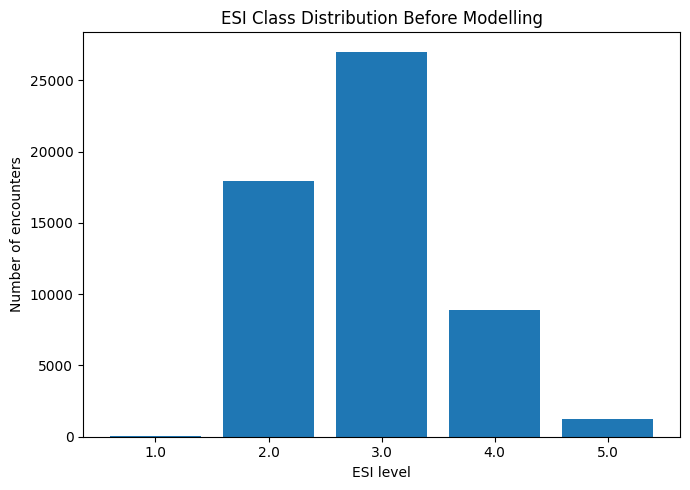

In [9]:
plt.figure(figsize=(7, 5))
plt.bar(target_summary["esi_level"], target_summary["count"])
plt.xlabel("ESI level")
plt.ylabel("Number of encounters")
plt.title("ESI Class Distribution Before Modelling")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "SOliver_Week6_ESI_Class_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

The ESI distribution is reviewed before modelling because an imbalanced target can make overall accuracy misleading. If ESI Level 1 cases are rare, a model may achieve acceptable-looking accuracy while still failing to identify the most critical patients. For this reason, recall for ESI Level 1 will be treated as the main clinical safety metric.

## 2. Feature Selection for the Interim Baseline

For the interim baseline, the feature set is intentionally simple and clinically defensible. It focuses on features that are expected to be available at or near triage, including vital signs, age, arrival information and selected chief complaint indicators. Possible post-triage outcome variables are excluded to reduce data leakage risk.

In [10]:
# Candidate features based on Week 5 feasibility review
candidate_features = [
    "age",
    "triage_vital_hr",
    "triage_vital_sbp",
    "triage_vital_dbp",
    "triage_vital_rr",
    "triage_vital_o2",
    "triage_vital_temp",
    "triage_vital_glucose",
    "arrivalmode",
    "arrival_mode",
    "arrival_transport",
    "cc_chestpain",
    "cc_shortnessofbreath"
]

# Keep only columns that actually exist in the dataset
selected_features = [col for col in candidate_features if col in df.columns]

print("Selected features:")
for feature in selected_features:
    print("-", feature)

print(f"\nNumber of selected features: {len(selected_features)}")

Selected features:
- age
- triage_vital_hr
- triage_vital_sbp
- triage_vital_dbp
- triage_vital_rr
- triage_vital_o2
- triage_vital_temp
- arrivalmode
- cc_chestpain
- cc_shortnessofbreath

Number of selected features: 10


In [11]:
model_df = df[selected_features + [TARGET]].copy()

# Drop records without the target label
model_df = model_df.dropna(subset=[TARGET])

X = model_df[selected_features]
y = model_df[TARGET].astype(int)

print(f"Modelling rows: {X.shape[0]:,}")
print(f"Modelling features: {X.shape[1]:,}")

y.value_counts().sort_index()

Modelling rows: 55,121
Modelling features: 10


,count
esi,
1,77
2,17924
3,27010
4,8896
5,1214


In [12]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_temp', 'cc_chestpain', 'cc_shortnessofbreath']
Categorical features: ['arrivalmode']


## 3. Train/Test Split

The data is split into 80% training and 20% testing. Stratification is used so that the train and test sets preserve the overall ESI class distribution as much as possible.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining ESI distribution:")
display(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTest ESI distribution:")
display(y_test.value_counts(normalize=True).sort_index().round(3))

Training set: (44096, 10)
Test set: (11025, 10)

Training ESI distribution:


,proportion
esi,
1,0.001
2,0.325
3,0.490
4,0.161
5,0.022



Test ESI distribution:


,proportion
esi,
1,0.001
2,0.325
3,0.490
4,0.161
5,0.022


In [14]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

## 4. Stratified Random Baseline

Before judging the logistic regression model, a stratified random baseline is used for comparison. This dummy model predicts according to the class distribution in the training data. A useful baseline model should perform better than this random baseline.

In [15]:
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="stratified", random_state=RANDOM_SEED))
])

dummy_model.fit(X_train, y_train)
dummy_preds = dummy_model.predict(X_test)

print("Dummy baseline accuracy:", round(accuracy_score(y_test, dummy_preds), 3))
print("\nDummy baseline classification report:")
print(classification_report(y_test, dummy_preds, zero_division=0))

Dummy baseline accuracy: 0.375

Dummy baseline classification report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        16
           2       0.33      0.33      0.33      3585
           3       0.49      0.50      0.49      5402
           4       0.15      0.15      0.15      1779
           5       0.05      0.05      0.05       243

    accuracy                           0.38     11025
   macro avg       0.20      0.20      0.20     11025
weighted avg       0.37      0.38      0.37     11025



## 5. Logistic Regression Baseline

A logistic regression model is used as the first baseline because it is simple, widely used and easier to explain than more complex models. Class weighting is used to reduce the risk of the model ignoring less common ESI categories.

In [16]:
log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_SEED
    ))
])

log_reg_model.fit(X_train, y_train)
log_reg_preds = log_reg_model.predict(X_test)

print("Logistic regression accuracy:", round(accuracy_score(y_test, log_reg_preds), 3))
print("\nLogistic regression classification report:")
print(classification_report(y_test, log_reg_preds, zero_division=0))

Logistic regression accuracy: 0.262

Logistic regression classification report:
              precision    recall  f1-score   support

           1       0.01      0.81      0.01        16
           2       0.53      0.31      0.39      3585
           3       0.58      0.20      0.29      5402
           4       0.26      0.30      0.28      1779
           5       0.05      0.56      0.09       243

    accuracy                           0.26     11025
   macro avg       0.29      0.44      0.22     11025
weighted avg       0.50      0.26      0.32     11025



## The confusion matrix

📚 **scikit-learn docs:** [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)  ·  [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)

Before you plot your own, here is how to read one. Our real matrix has all five ESI levels, but the idea is clearest with a single class — 'urgent' vs 'not':

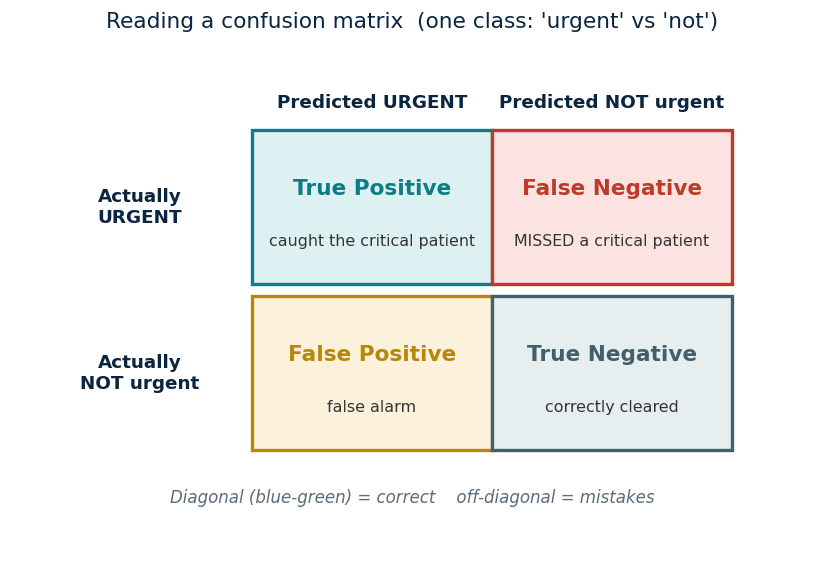

<div style="border-left:6px solid #6C5CE7;background:#6C5CE714;padding:10px 14px;margin:6px 0;border-radius:4px"><b style="color:#6C5CE7">🧩 CODE IN PLAIN ENGLISH</b><br>A <b>confusion matrix</b> is a grid: rows are the <i>true</i> ESI level, columns are what the model <i>predicted</i>. The diagonal is where it got it right. Everything off the diagonal is a mistake — and the matrix shows you <i>which</i> levels get confused for which. That detail is invisible in a single accuracy number.</div>

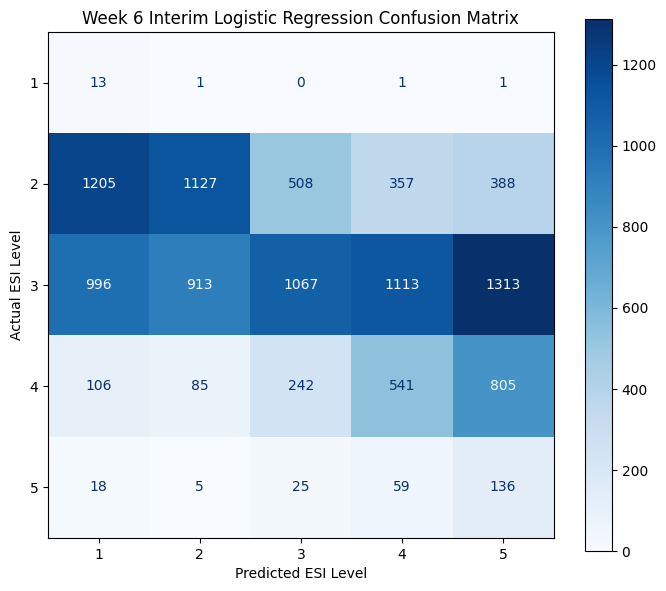

In [17]:
labels = sorted(y_test.unique())

cm = confusion_matrix(y_test, log_reg_preds, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Week 6 Interim Logistic Regression Confusion Matrix")
ax.set_xlabel("Predicted ESI Level")
ax.set_ylabel("Actual ESI Level")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "SOliver_Week6_Interim_Logistic_Regression_Confusion_Matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
comparison_rows = []

for model_name, preds in [
    ("Stratified random baseline", dummy_preds),
    ("Logistic regression baseline", log_reg_preds)
]:
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)

    comparison_rows.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, preds),
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "esi_1_recall": report.get("1", {}).get("recall", np.nan)
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.round(3)

,model,accuracy,macro_f1,weighted_f1,esi_1_recall
0,Stratified random baseline,0.375,0.204,0.375,0.000
1,Logistic regression baseline,0.262,0.215,0.320,0.812


## 6. Interim Primary Metric Choice

For this baseline triage model, my primary clinical metric is recall for ESI Level 1. This is because ESI Level 1 represents the most critical patients, where delayed recognition could lead to serious harm. Overall accuracy is not enough for this dataset because a model could perform well on common lower-acuity categories while still missing rare, high-acuity patients. In a triage context, the most concerning failure mode is under-triage: predicting a less urgent ESI level for a patient who is actually ESI Level 1. For this reason, the interim evaluation focuses not only on whether the model is correct overall, but whether it can identify the highest-risk patients.

## 7. Interim Conclusion

This interim notebook trained a logistic regression baseline and compared it against a stratified random baseline. The initial evaluation includes accuracy, precision, recall, F1-score and a confusion matrix. The main clinical concern is whether the model misses ESI Level 1 patients, because those patients are the highest acuity and would be most harmed by delayed recognition.

For the final Week 6 submission, the next steps are to add a bounded-depth decision tree, compare both models against the dummy baseline, explain macro versus weighted F1, finalise the failure-mode reflection and record a 1-minute clinical explainer video for Dr. Reyes.